# 06. 결과 비교와 figure 생성

**성공률, 자원 사용량, solution quality, MP feasibility 를 하나의 "우승" metric 으로
합치지 않는다.** 각각 별도로 본다.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

from cflp_bd_qa_ex2.config.loader import load_config
from cflp_bd_qa_ex2.data.io import load_all_instances

cfg = load_config(ROOT / "config" / "experiments" / "pilot.yaml")
instances = load_all_instances(ROOT / "data" / "raw")
by_id = {i.instance_id: i for i in instances}
print("configuration_hash:", cfg["configuration_hash"][:16])


configuration_hash: 52f385981dd5f1ea


## 1. 결과 로드

`gurobi_controlled`, `sa_end_to_end`, `qa_end_to_end` 를 각각 읽어 합친다.
`trajectory_source` 열로 항상 구분된다.

In [2]:
RESULTS = ROOT / "results"

def read_csv(path):
    """없으면 빈 DataFrame 을 돌려준다."""
    return pd.read_csv(path) if Path(path).exists() else pd.DataFrame()

ground_truth = read_csv(RESULTS / "ground_truth" / "ground_truth.csv")
benders_iterations = read_csv(RESULTS / "benders" / "benders_iterations.csv")
benders_runs = read_csv(RESULTS / "benders" / "benders_runs.csv")
sa_iterations = read_csv(RESULTS / "sa" / "sa_iterations.csv")
sa_runs = read_csv(RESULTS / "sa" / "sa_runs.csv")
# QA 결과는 topology 별로 나뉜다 (qa_iterations_pegasus.csv 등).
# 구형 무접미사 파일이 함께 있으면 같은 실행이 두 번 집계되므로,
# topology 파일이 있으면 구형 파일은 무시한다(공용 로더가 경고를 출력한다).
from cflp_bd_qa_ex2.evaluation.results import load_qa_results

qa_iterations = load_qa_results(RESULTS / "qa", "qa_iterations")
qa_runs = load_qa_results(RESULTS / "qa", "qa_runs")
embedding_frame = read_csv(RESULTS / "embedding" / "embedding_trials.csv")

iteration_frame = pd.concat(
    [f for f in (benders_iterations, sa_iterations, qa_iterations) if not f.empty],
    ignore_index=True,
)
run_frame = pd.concat(
    [f for f in (benders_runs, sa_runs, qa_runs) if not f.empty], ignore_index=True
)

# --- configuration_hash 필터 ---
# 여러 설정의 결과가 섞이면 같은 instance 의 ground-truth 행이 여러 개가 되어
# gap 계산이 조용히 틀리거나 서로 다른 설정이 한 선으로 이어진다.
TARGET_HASH = cfg["configuration_hash"]

def filter_hash(frame, label):
    """configuration_hash 가 일치하는 행만 남긴다."""
    if frame.empty or "configuration_hash" not in frame.columns:
        return frame
    hashes = sorted(frame["configuration_hash"].dropna().unique())
    if len(hashes) > 1:
        print(f"  [{label}] configuration_hash {len(hashes)}종 발견 -> {TARGET_HASH[:12]} 만 사용")
    return frame[frame["configuration_hash"] == TARGET_HASH]

ground_truth = filter_hash(ground_truth, "ground_truth")
iteration_frame = filter_hash(iteration_frame, "iterations")
run_frame = filter_hash(run_frame, "runs")
embedding_frame = filter_hash(embedding_frame, "embedding")

for name, frame in [("iterations", iteration_frame), ("runs", run_frame),
                    ("embedding", embedding_frame)]:
    print(f"{name:10s}: {len(frame):5d}행")
if not run_frame.empty:
    print()
    print(run_frame["trajectory_source"].value_counts())


  [iterations] configuration_hash 2종 발견 -> 52f385981dd5 만 사용
  [runs] configuration_hash 2종 발견 -> 52f385981dd5 만 사용
iterations:    50행
runs      :     5행
embedding :   320행

trajectory_source
qa_end_to_end    5
Name: count, dtype: int64


## 2. Gap 계산

**ground truth 가 `OPTIMAL` 일 때만** gap 을 계산한다.
Time limit 이나 `GUROBI_SIZE_LIMIT` 행은 gap 이 `NaN` 으로 남는다.

In [3]:
from cflp_bd_qa_ex2.evaluation.metrics import compute_gap

# instance_id 가 유일한지 확인한 뒤 index 로 쓴다.
if not ground_truth.empty:
    duplicated = ground_truth["instance_id"].duplicated().sum()
    assert duplicated == 0, f"ground_truth 에 중복 instance_id {duplicated}건 (hash 필터 확인 필요)"
    truth = ground_truth.set_index("instance_id")
else:
    truth = pd.DataFrame()

def gap_for(row):
    """행 하나의 final gap(%)을 계산한다."""
    if truth.empty or row["instance_id"] not in truth.index:
        return None
    entry = truth.loc[row["instance_id"]]
    return compute_gap(row.get("best_upper_bound"),
                       entry.get("objective_opt"),
                       entry.get("ground_truth_status"))

if not run_frame.empty:
    run_frame["final_gap_percent"] = run_frame.apply(gap_for, axis=1)
    display(run_frame[["instance_id", "instance_name", "trajectory_source",
                       "termination_status", "benders_iterations",
                       "best_upper_bound", "final_gap_percent"]])


,instance_id,instance_name,trajectory_source,termination_status,benders_iterations,best_upper_bound,final_gap_percent
23,4x12_s100,4x12,qa_end_to_end,STALLED_DUPLICATE_CUT,6,5115.536914,None
24,8x25_s200,8x25,qa_end_to_end,STALLED_DUPLICATE_CUT,11,9447.416647,None
25,4x12_s100,4x12,qa_end_to_end,OPTIMAL,3,4904.433098,None
26,8x25_s200,8x25,qa_end_to_end,STALLED_DUPLICATE_CUT,10,9447.416647,None
27,16x50_s300,16x50,qa_end_to_end,NO_FEASIBLE_SAMPLE,20,18825.020717,None


## 3. 상태 분포

실패를 성공으로 바꾸거나 행을 삭제하지 않았는지 확인한다.

In [4]:
if not run_frame.empty:
    print("termination_status x trajectory_source:")
    display(pd.crosstab(run_frame["termination_status"], run_frame["trajectory_source"]))
    print("\ndual guard (termination_status 와 별개 열):")
    display(run_frame.groupby(["dual_minimality_status", "dual_guard_action"]).size())


termination_status x trajectory_source:


trajectory_source,qa_end_to_end
termination_status,
NO_FEASIBLE_SAMPLE,1
OPTIMAL,1
STALLED_DUPLICATE_CUT,3



dual guard (termination_status 와 별개 열):


dual_minimality_status  dual_guard_action
MINIMAL                 NONE                 5
dtype: int64

## 4. Figure 생성

명세 24절이 요구하는 figure 를 모두 생성한다.

In [5]:
from cflp_bd_qa_ex2.evaluation.plots import generate_all_figures

figures = RESULTS / "figures"
paths = generate_all_figures(iteration_frame, run_frame, embedding_frame, figures)
for path in paths:
    print(path.name)
print(f"\n총 {len(paths)}개 figure")


c:\Users\User\Desktop\KMJ\Study\Quantum\cflp-bd-qa-ex2\src\cflp_bd_qa_ex2\evaluation\plots.py:149: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data = frame.assign(_value=values).dropna(subset=["_value"])
c:\Users\User\Desktop\KMJ\Study\Quantum\cflp-bd-qa-ex2\src\cflp_bd_qa_ex2\evaluation\plots.py:149: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data = frame.assign(_value=values).dropna(subset=["_value"])
c:\Users\User\Desktop\KMJ\Study\Quantum\cflp-bd-qa-ex2\src\cflp_bd_qa_ex2\evaluation\plots.py:149: PerformanceWarning: Dat

fig01_final_gap_by_solver.png
fig02_mp_feasible_rate.png
fig03_bound_trajectory.png
fig04_logical_variables.png
fig05_logical_edges.png
fig06_qubo_density.png
fig07_coefficient_range.png
fig08_physical_qubits.png
fig09a_mean_chain_length.png
fig09b_max_chain_length.png
fig10_embedding_time.png
fig11_embedding_success_heatmap_micro.png
fig11_embedding_success_heatmap_macro.png
fig11b_embedding_success_by_iteration.png
fig12_ideal_vs_actual.png
fig13_chain_break_vs_feasibility.png
fig14_slack_bit_composition.png

총 17개 figure


fig01_final_gap_by_solver.png


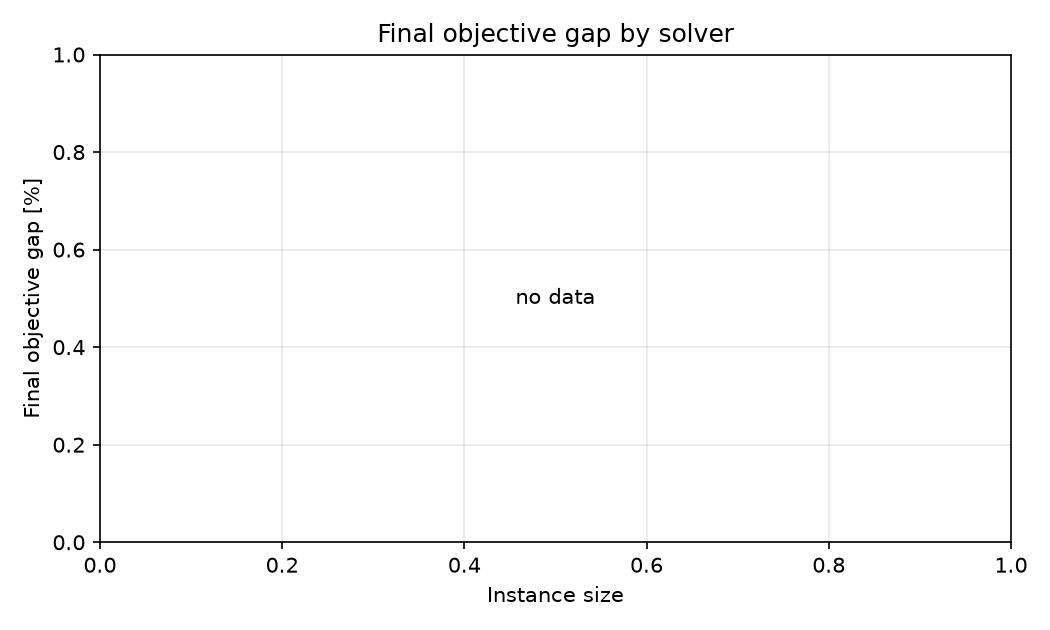

fig02_mp_feasible_rate.png


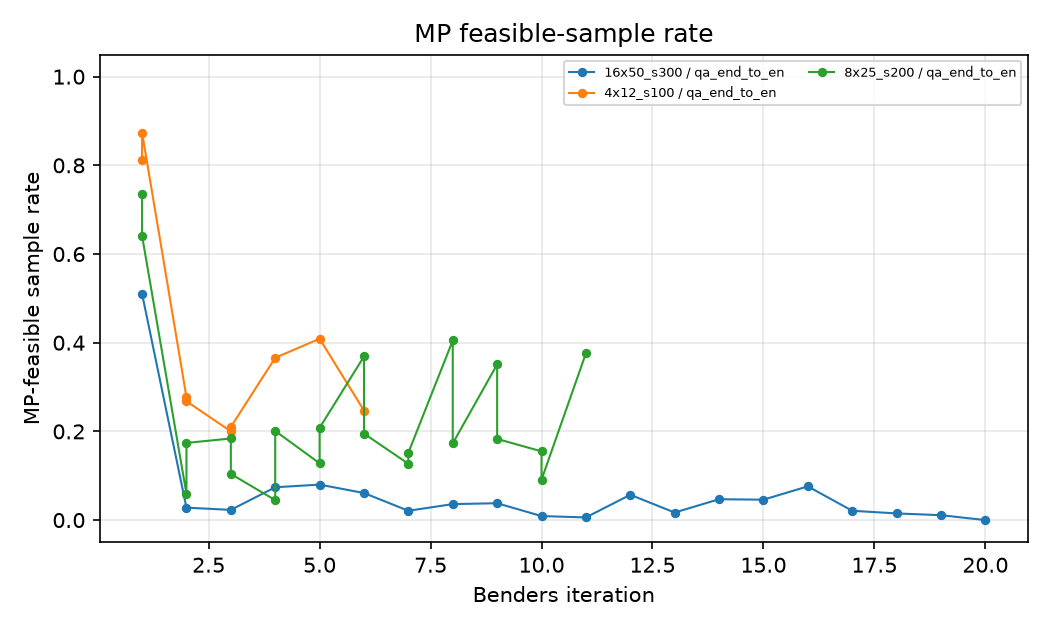

fig03_bound_trajectory.png


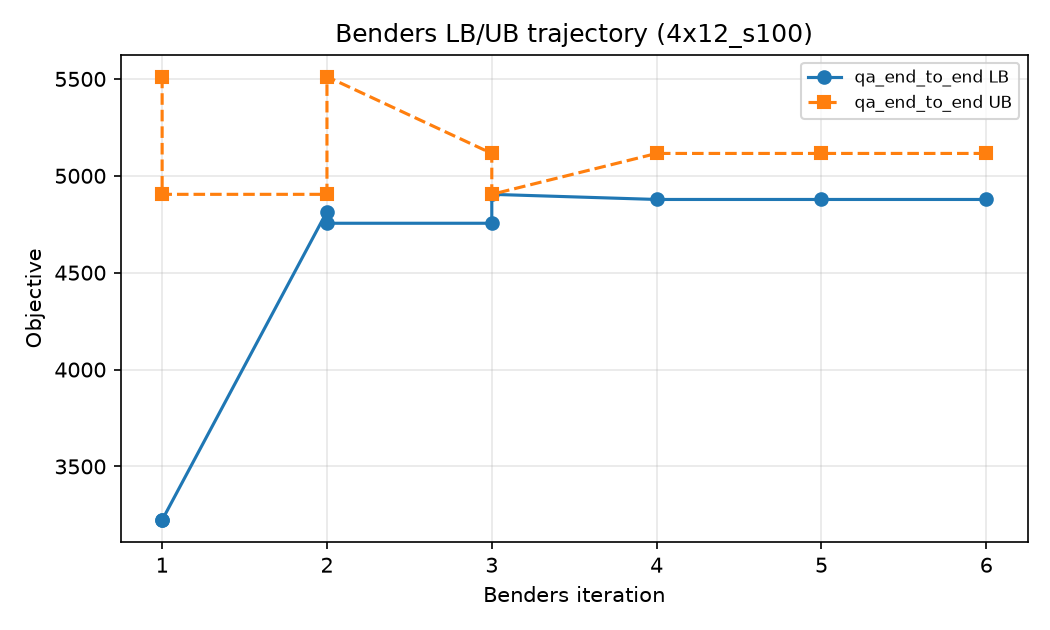

fig04_logical_variables.png


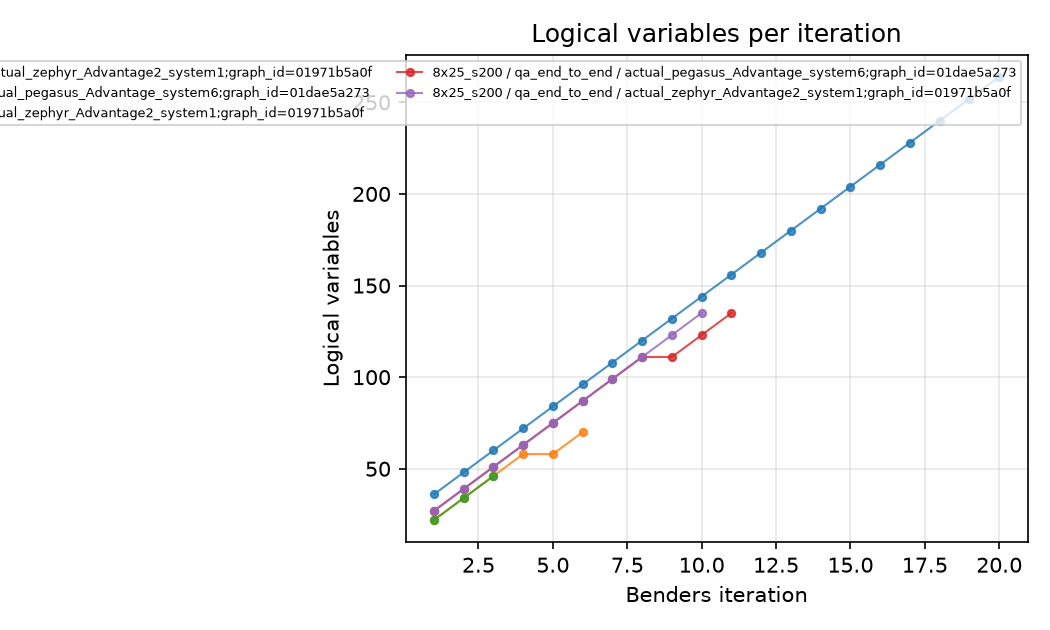

fig05_logical_edges.png


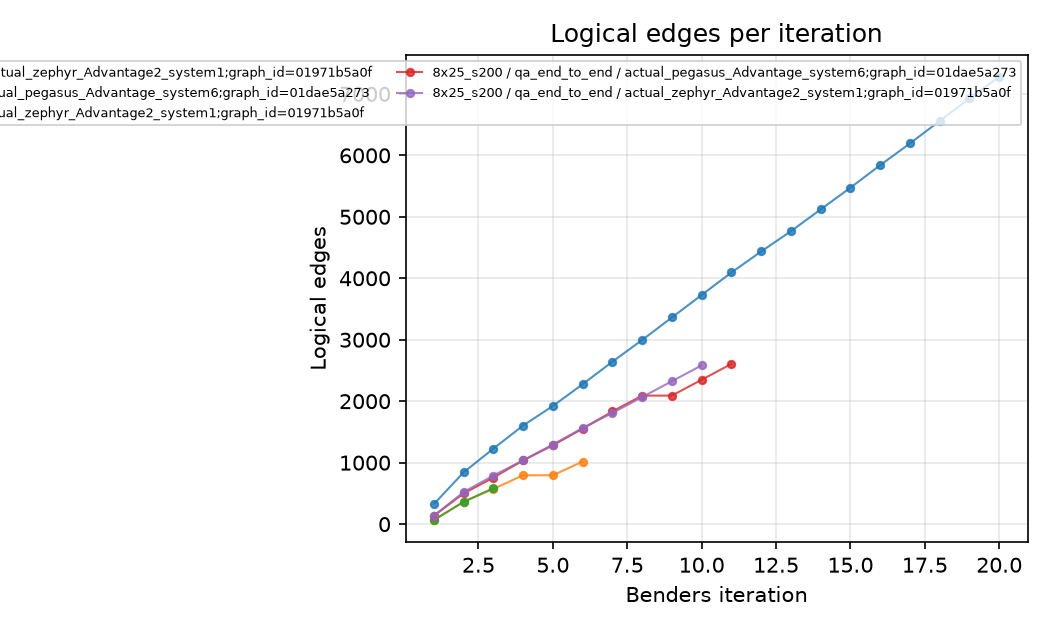

fig06_qubo_density.png


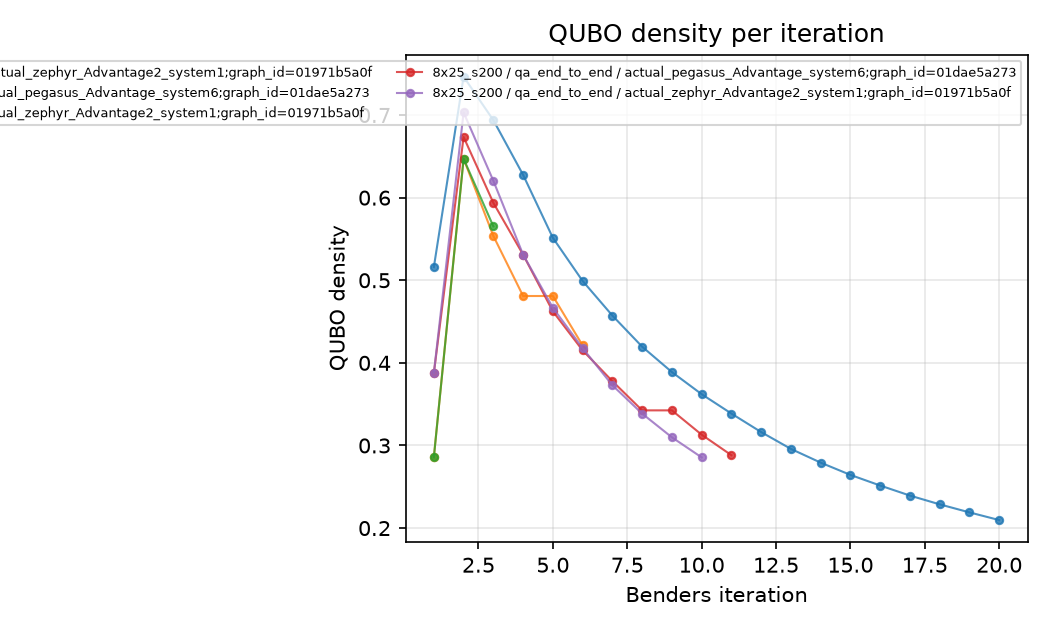

fig07_coefficient_range.png


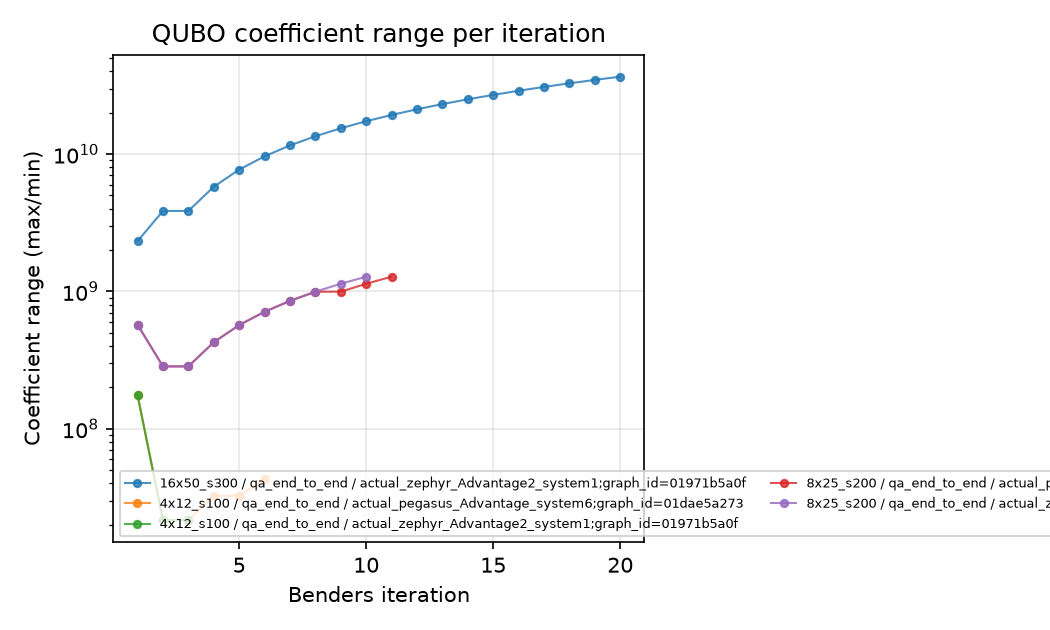

fig08_physical_qubits.png


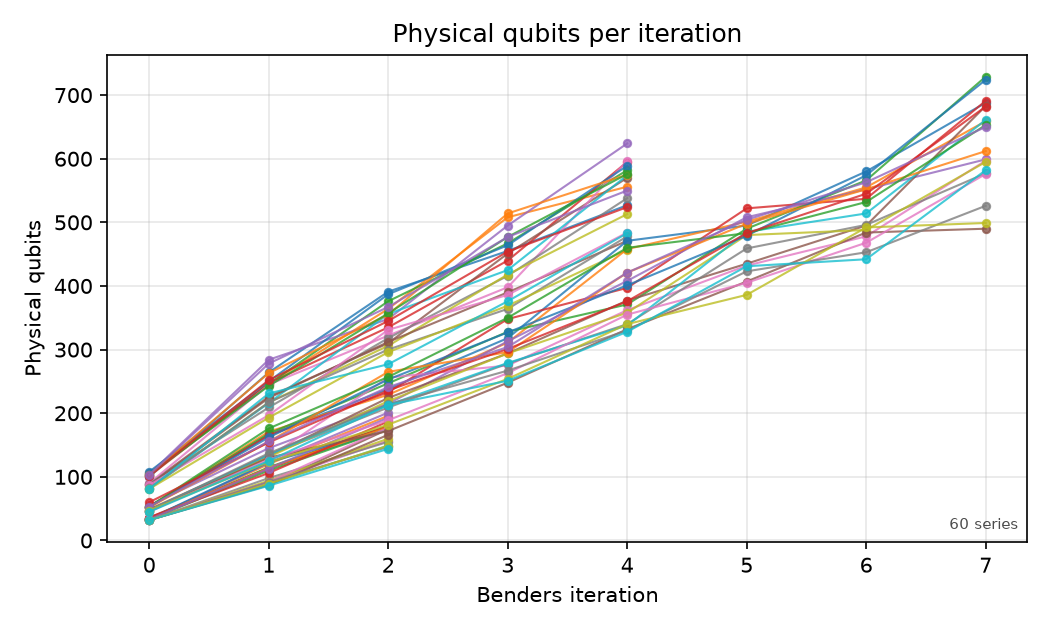

fig09a_mean_chain_length.png


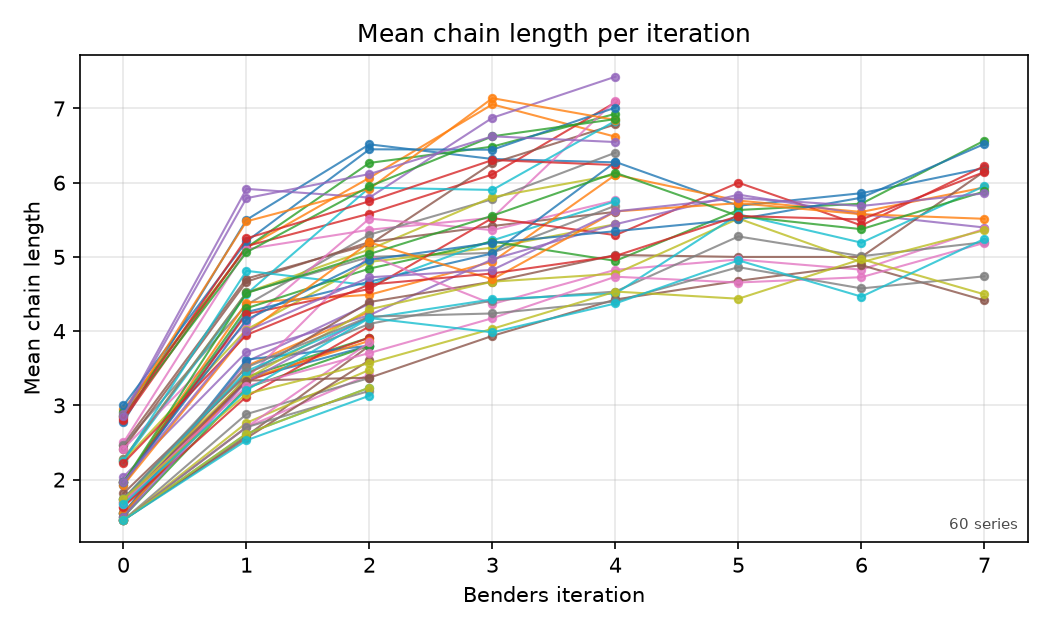

fig09b_max_chain_length.png


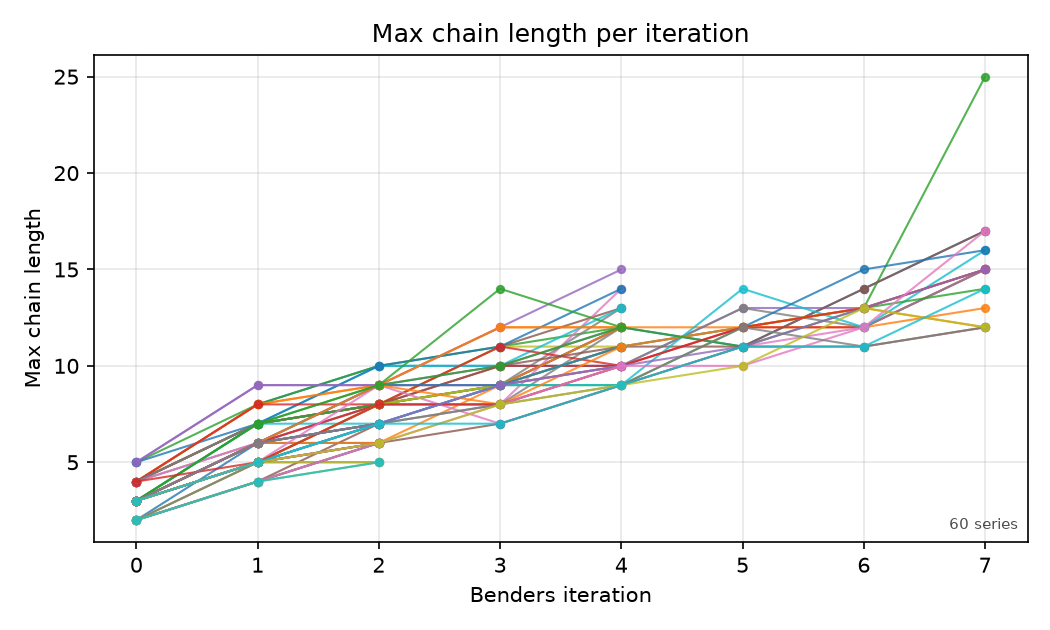

fig10_embedding_time.png


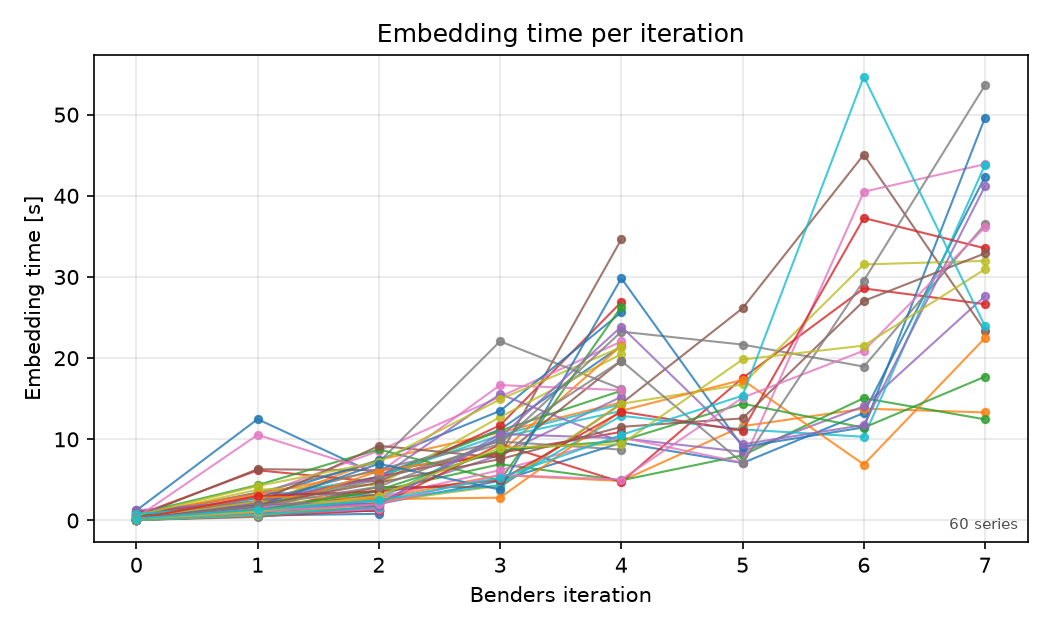

fig11_embedding_success_heatmap_micro.png


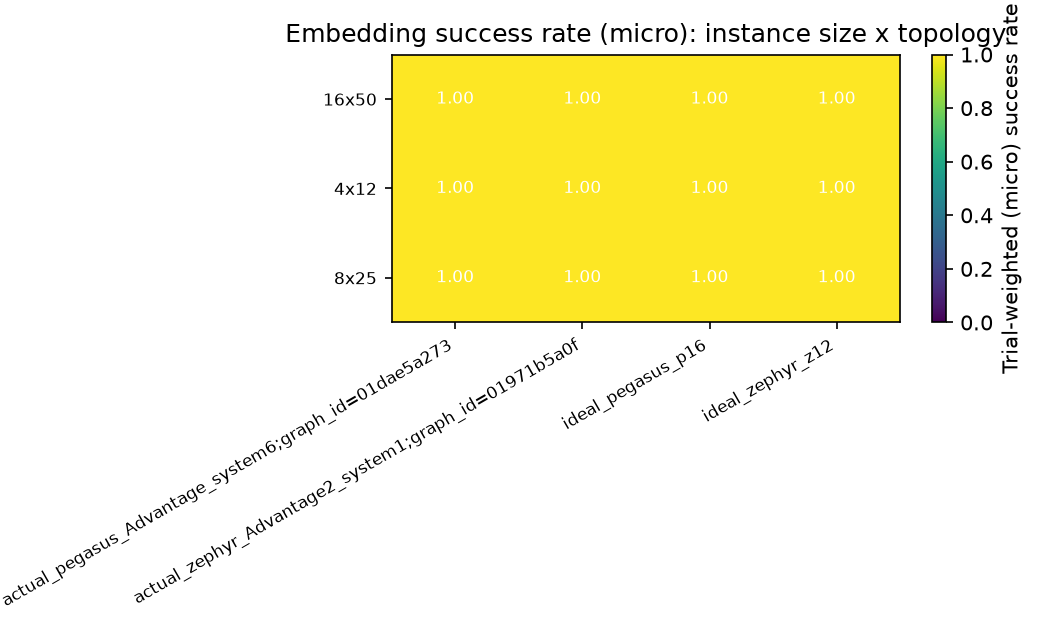

fig11_embedding_success_heatmap_macro.png


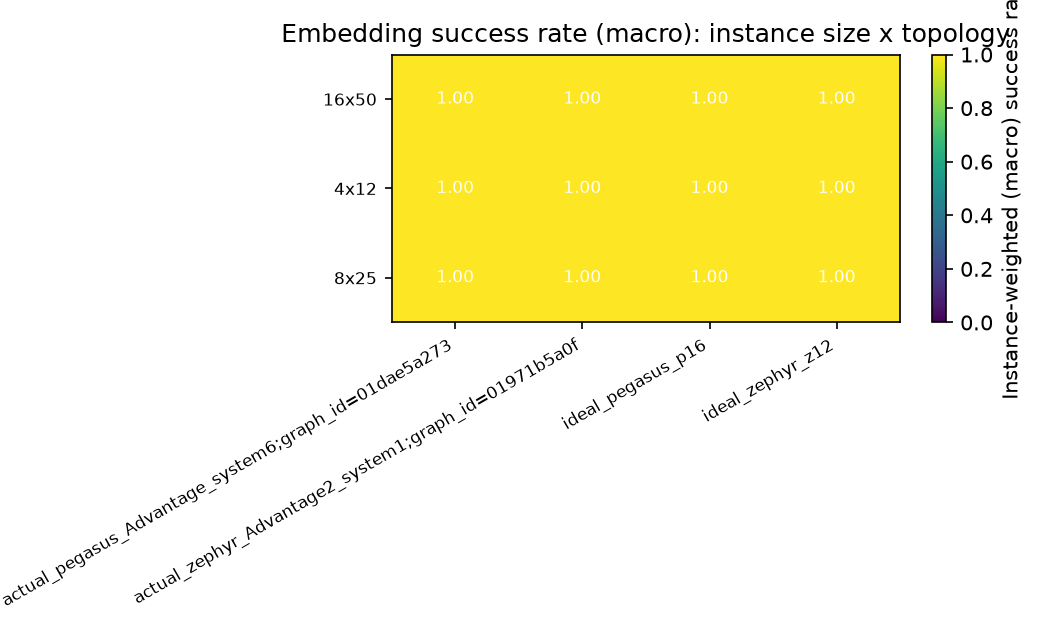

fig11b_embedding_success_by_iteration.png


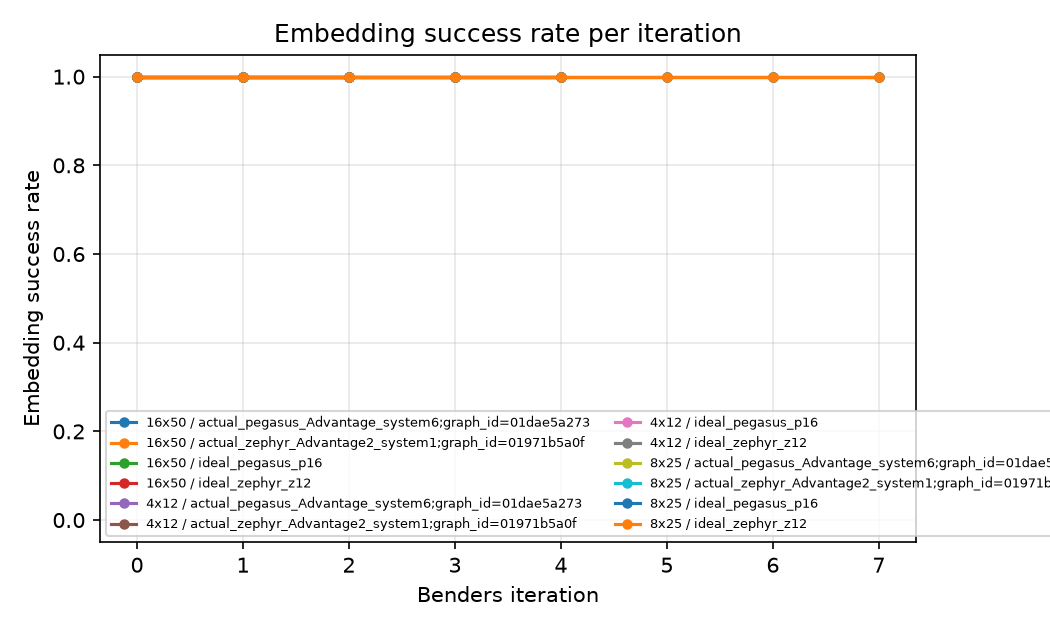

fig12_ideal_vs_actual.png


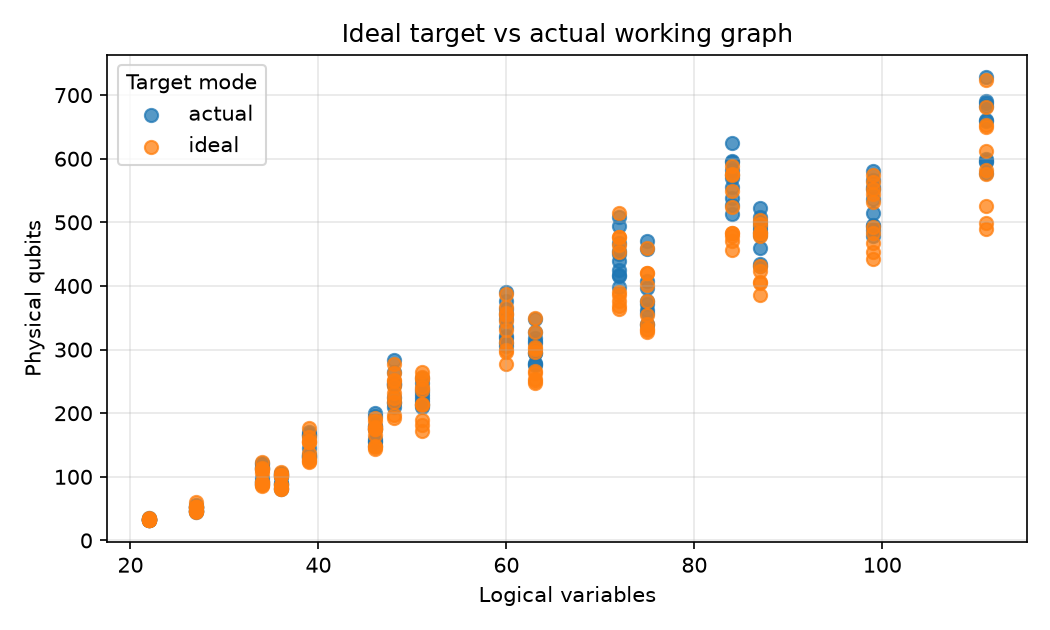

fig13_chain_break_vs_feasibility.png


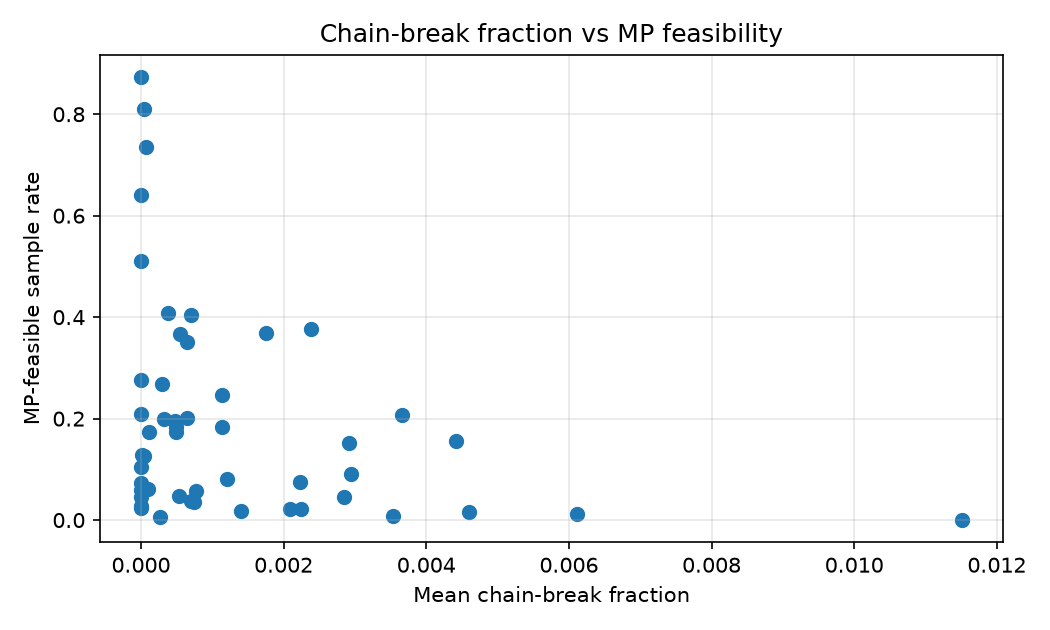

fig14_slack_bit_composition.png


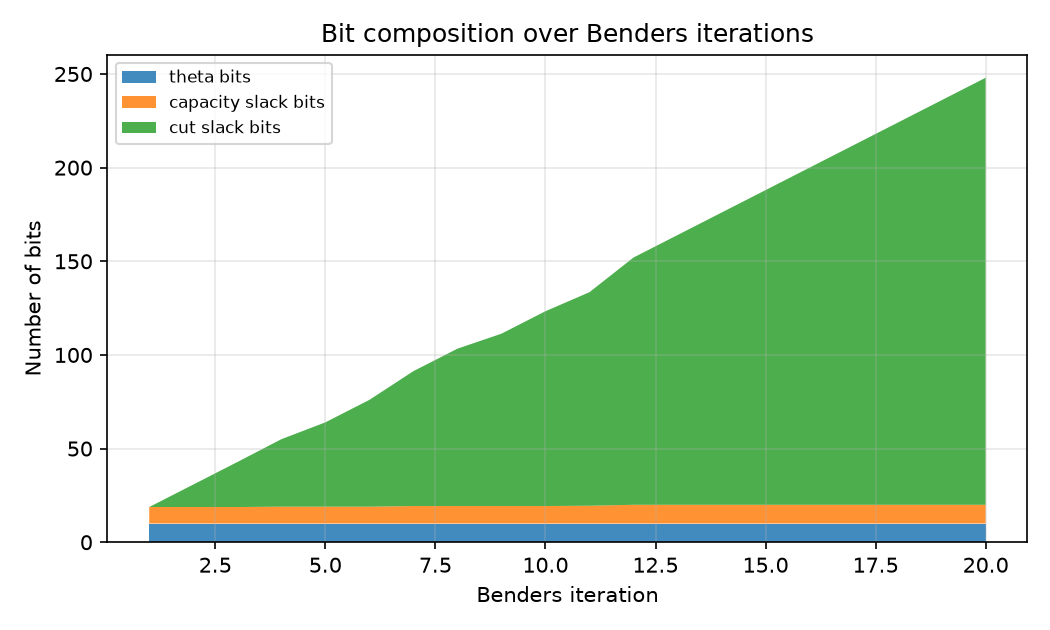

In [6]:
from IPython.display import Image, display

for path in paths:
    print(path.name)
    display(Image(filename=str(path)))


## 5. Iteration 성장 요약

QUBO 변수 수의 **정의**는 다음이다.

```
n_QUBO = n_f + b_theta + b_cap + sum_k b_k^cut
```

`n_f + b_theta + b_cap + 12K` 는 관측된 empirical model 일 뿐이며 정의가 아니다.

In [7]:
growth_rows = []
if not iteration_frame.empty and "logical_variables" in iteration_frame:
    for key, group in iteration_frame.dropna(subset=["logical_variables"]).groupby(
        ["instance_id", "trajectory_source"]
    ):
        group = group.sort_values("benders_iteration")
        variables = group["logical_variables"].to_numpy(dtype=float)
        if len(variables) >= 2:
            growth_rows.append({
                "instance_id": key[0],
                "trajectory_source": key[1],
                "iterations": len(variables),
                "variables_first": variables[0],
                "variables_last": variables[-1],
                "mean_increment_per_iteration": float(np.diff(variables).mean()),
            })

growth = pd.DataFrame(growth_rows)
if not growth.empty:
    print("iteration 당 변수 증가량 (관측):")
    display(growth)
    print("전체 평균 증가량: %.3f" % growth["mean_increment_per_iteration"].mean())
    print("참고: b_theta + log2(1/r_cut) = %d + %.0f = %d"
          % (cfg["encoding"]["theta"]["bits"],
             np.log2(1 / cfg["encoding"]["cut_slack"]["delta_ratio_to_theta"]),
             cfg["encoding"]["theta"]["bits"]
             + int(np.log2(1 / cfg["encoding"]["cut_slack"]["delta_ratio_to_theta"]))))
else:
    print("성장 분석에 충분한 iteration 데이터가 없다.")


iteration 당 변수 증가량 (관측):


,instance_id,trajectory_source,iterations,variables_first,variables_last,mean_increment_per_iteration
0,16x50_s300,qa_end_to_end,20,36.0,264.0,12.0
1,4x12_s100,qa_end_to_end,9,22.0,70.0,6.0
2,8x25_s200,qa_end_to_end,21,27.0,135.0,5.4


전체 평균 증가량: 7.800
참고: b_theta + log2(1/r_cut) = 10 + 2 = 12


## 6. Embedding 요약

ideal 과 actual 을 분리해서 본다.

In [8]:
if not embedding_frame.empty:
    summary = embedding_frame.groupby(
        ["instance_name", "topology_label", "target_mode"]
    ).agg(
        trials=("success", "size"),
        success_rate=("success", "mean"),
        mean_embedding_time=("embedding_time", "mean"),
    ).reset_index()
    display(summary)

    numeric = embedding_frame[embedding_frame["success"].astype(bool)].copy()
    for column in ("physical_qubits", "mean_chain_length", "max_chain_length",
                   "embedding_overhead"):
        numeric[column] = pd.to_numeric(numeric[column], errors="coerce")
    display(numeric.groupby(["instance_name", "topology_label"])[
        ["physical_qubits", "mean_chain_length", "max_chain_length", "embedding_overhead"]
    ].mean())
else:
    print("embedding 결과가 없다.")


,instance_name,topology_label,target_mode,trials,success_rate,mean_embedding_time
0,16x50,actual_pegasus_Advantage_system6;graph_id=01da...,actual,25,1.0,8.141505
1,16x50,actual_zephyr_Advantage2_system1;graph_id=0197...,actual,25,1.0,9.216327
2,16x50,ideal_pegasus_p16,ideal,25,1.0,7.891705
3,16x50,ideal_zephyr_z12,ideal,25,1.0,7.762064
4,4x12,actual_pegasus_Advantage_system6;graph_id=01da...,actual,15,1.0,1.079537
5,4x12,actual_zephyr_Advantage2_system1;graph_id=0197...,actual,15,1.0,1.055387
6,4x12,ideal_pegasus_p16,ideal,15,1.0,1.065779
7,4x12,ideal_zephyr_z12,ideal,15,1.0,0.949258
8,8x25,actual_pegasus_Advantage_system6;graph_id=01da...,actual,40,1.0,8.810032
9,8x25,actual_zephyr_Advantage2_system1;graph_id=0197...,actual,40,1.0,13.458859


physical_qubits  \
instance_name topology_label                                                        
16x50         actual_pegasus_Advantage_system6;graph_id=01dae...       354.640000   
              actual_zephyr_Advantage2_system1;graph_id=01971...       322.240000   
              ideal_pegasus_p16                                        352.640000   
              ideal_zephyr_z12                                         290.160000   
4x12          actual_pegasus_Advantage_system6;graph_id=01dae...       112.466667   
              actual_zephyr_Advantage2_system1;graph_id=01971...        94.466667   
              ideal_pegasus_p16                                        109.600000   
              ideal_zephyr_z12                                          92.600000   
8x25          actual_pegasus_Advantage_system6;graph_id=01dae...       365.950000   
              actual_zephyr_Advantage2_system1;graph_id=01971...       327.250000   
              ideal_pegasus_p16                                        362.925000   
              ideal_zephyr_z12                                         296.875000   

                                                                  mean_chain_length  \
instance_name topology_label                                                          
16x50         actual_pegasus_Advantage_system6;graph_id=01dae...           5.542389   
              actual_zephyr_Advantage2_system1;graph_id=01971...           4.981690   
              ideal_pegasus_p16                                            5.521222   
              ideal_zephyr_z12                                             4.537333   
4x12          actual_pegasus_Advantage_system6;graph_id=01dae...           3.014004   
              actual_zephyr_Advantage2_system1;graph_id=01971...           2.542393   
              ideal_pegasus_p16                                            2.940897   
              ideal_zephyr_z12                                             2.494141   
8x25          actual_pegasus_Advantage_system6;graph_id=01dae...           4.867712   
              actual_zephyr_Advantage2_system1;graph_id=01971...           4.331352   
              ideal_pegasus_p16                                            4.848204   
              ideal_zephyr_z12                                             3.954050   

                                                                  max_chain_length  \
instance_name topology_label                                                         
16x50         actual_pegasus_Advantage_system6;graph_id=01dae...          8.920000   
              actual_zephyr_Advantage2_system1;graph_id=01971...          8.320000   
              ideal_pegasus_p16                                           8.920000   
              ideal_zephyr_z12                                            7.560000   
4x12          actual_pegasus_Advantage_system6;graph_id=01dae...          5.266667   
              actual_zephyr_Advantage2_system1;graph_id=01971...          4.066667   
              ideal_pegasus_p16                                           4.933333   
              ideal_zephyr_z12                                            3.933333   
8x25          actual_pegasus_Advantage_system6;graph_id=01dae...          9.750000   
              actual_zephyr_Advantage2_system1;graph_id=01971...          9.350000   
              ideal_pegasus_p16                                           9.575000   
              ideal_zephyr_z12                                            8.400000   

                                                                  embedding_overhead  
instance_name topology_label                                                          
16x50         actual_pegasus_Advantage_system6;graph_id=01dae...            5.542389  
              actual_zephyr_Advantage2_system1;graph_id=01971...            4.981690  
              ideal_pegasus_p16                                             5.521222  
              id

## 7. 해석 (읽는 법)

각 figure 를 **따로** 읽는다. 합산 점수를 만들지 않는다.

1. **fig01 final gap** — ground truth 가 `OPTIMAL` 인 행만 값이 있다.
   `GUROBI_SIZE_LIMIT` 행은 비어 있는 것이 정상이다.
2. **fig02 MP feasible rate** — iteration 과 함께 떨어지면 cut 누적으로 QUBO 가
   어려워지고 있다는 신호이다.
3. **fig03 LB/UB** — LB 단조 증가, UB 이상이 아님. 이것이 깨지면 구현 오류이다.
4. **fig04/05 variables/edges** — 증가 기울기가 인스턴스 크기가 아니라
   theta 해상도에 지배되는지 확인한다.
5. **fig06 density** — cut 은 모든 y bit 와 theta bit 를 연결하므로 density 가
   초기에 증가하다가 slack bit 가 늘면서 희석될 수 있다.
6. **fig07 coefficient range** — 로그 축. **비율**이다.
   이 값이 QA 난이도의 핵심 지표이다.
7. **fig08~10 embedding 자원** — physical qubits, chain length, 탐색 시간.
8. **fig11 heatmap** — 성공률. 실패는 "이 budget 에서 못 찾음" 이다.
9. **fig12 ideal vs actual** — 결함이 자원 소모에 주는 영향.
   actual 데이터가 없으면 비어 있다.
10. **fig13 chain-break vs feasibility** — QA 없이는 비어 있다.
11. **fig14 bit composition** — theta/capacity 는 고정, cut slack 만 누적된다.